In [1]:
# MEMBER 1
# Dataset Loading + Duplicate Handling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

# Check files inside the downloaded folder
print("\nFiles in dataset folder:")
print(os.listdir(path))

# Load the dataset
file_path = os.path.join(path, "credit_risk_dataset.csv")

df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")

# Display first 5 rows
print(df.head())


# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDuplicates after removing:")
print(df.duplicated().sum())

# Check dataset shape after duplicate removal
print("\nDataset shape:")
print(df.shape)

100%|██████████| 368k/368k [00:00<00:00, 533kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1

Files in dataset folder:
['credit_risk_dataset.csv']

Dataset loaded successfully!
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C     

First 5 rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                 

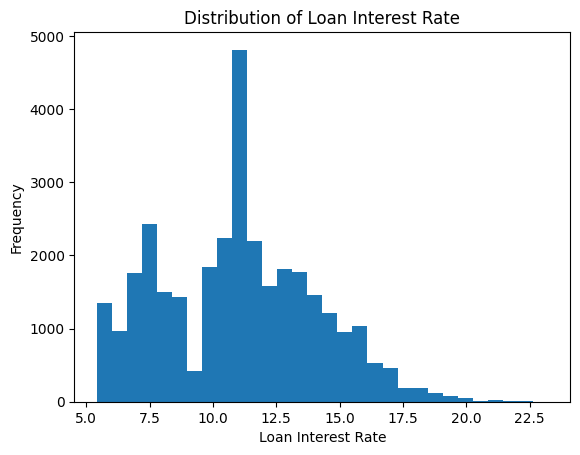

In [2]:
# ==============================
# MEMBER 2
# Dataset Inspection + Missing Data Handling
# ==============================

# First 5 rows
print("First 5 rows:")
print(df.head())

# Last 5 rows
print("\nLast 5 rows:")
print(df.tail())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Include categorical columns in summary
print("\nComplete Summary:")
print(df.describe(include="all"))

# Check missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Handle missing numerical values using median
if "person_emp_length" in df.columns:
    df["person_emp_length"] = df["person_emp_length"].fillna(
        df["person_emp_length"].median()
    )

if "loan_int_rate" in df.columns:
    df["loan_int_rate"] = df["loan_int_rate"].fillna(
        df["loan_int_rate"].median()
    )

# Final missing value check
print("\nMissing values after cleaning:")
print(df.isnull().sum())


# EDA Visualization
import matplotlib.pyplot as plt

plt.hist(df["loan_int_rate"], bins=30)
plt.title("Distribution of Loan Interest Rate")
plt.xlabel("Loan Interest Rate")
plt.ylabel("Frequency")
plt.show()

Loan Status Distribution:
loan_status
0    25327
1     7089
Name: count, dtype: int64

Loan Status Percentage:
loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64


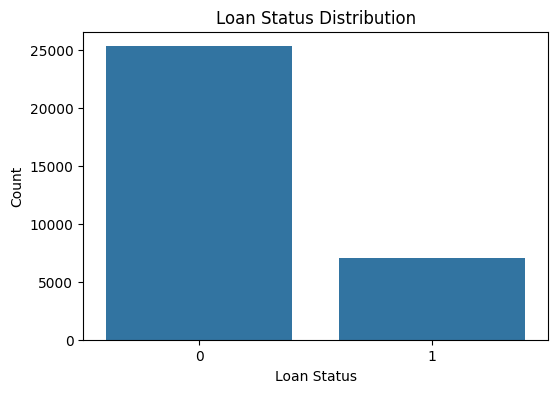

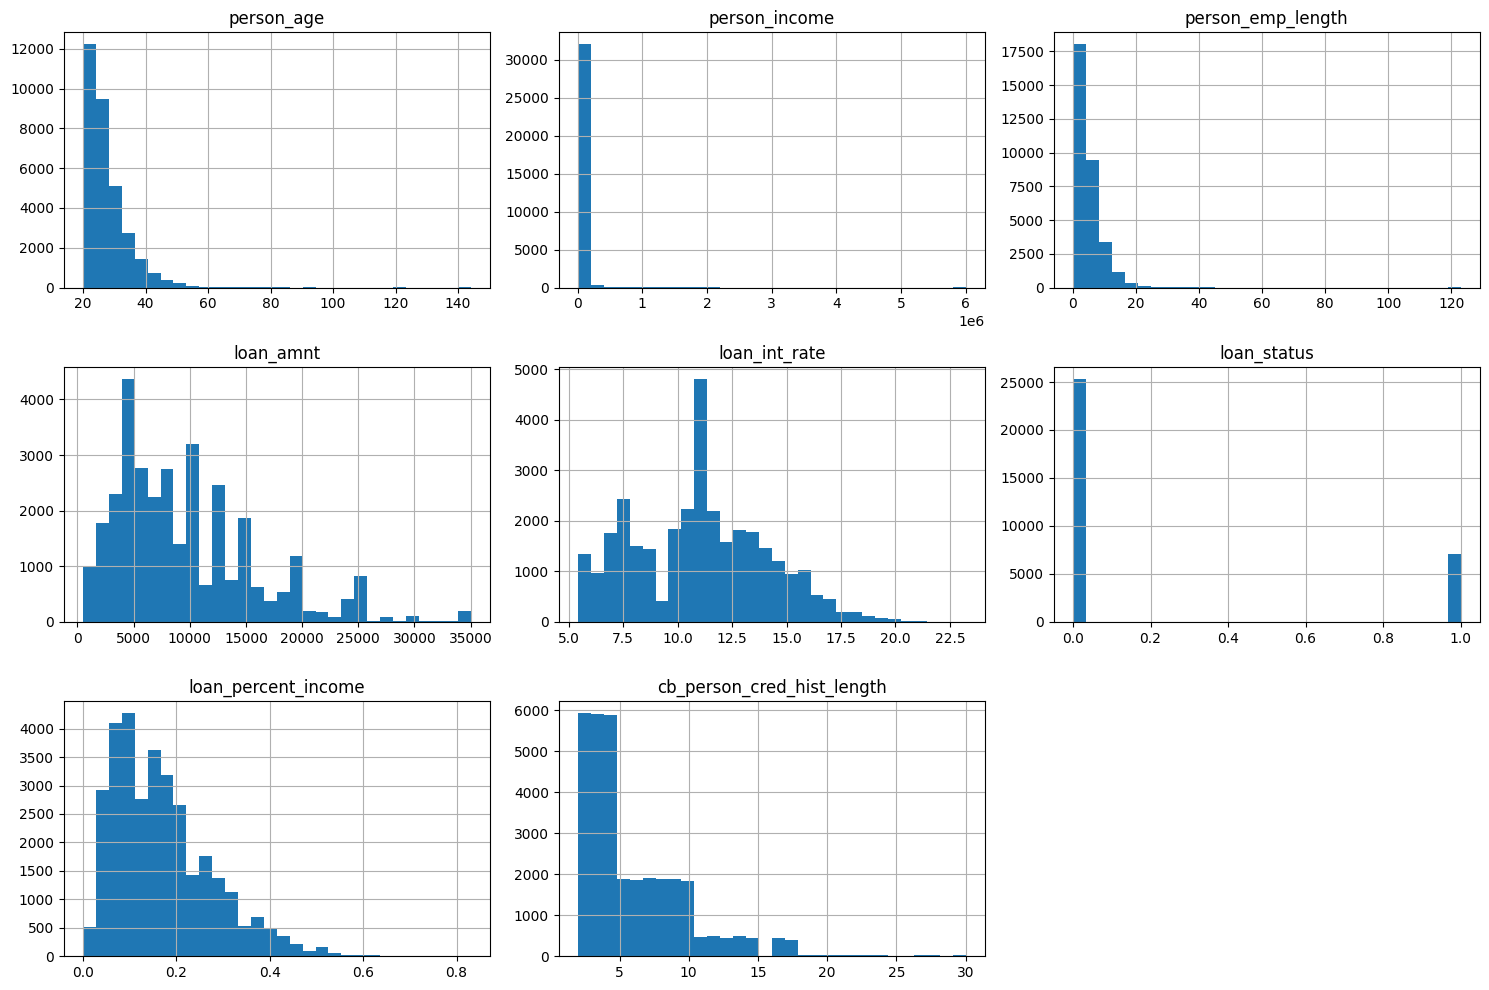

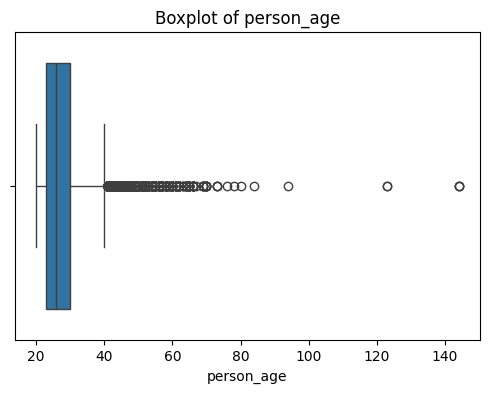

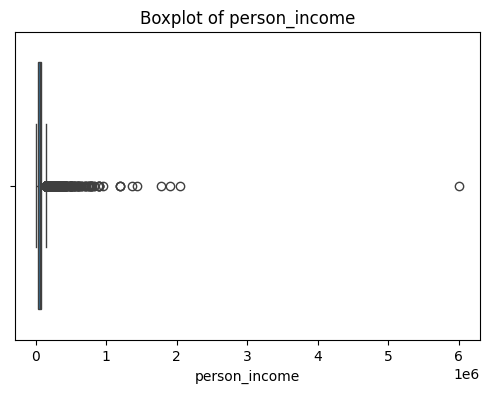

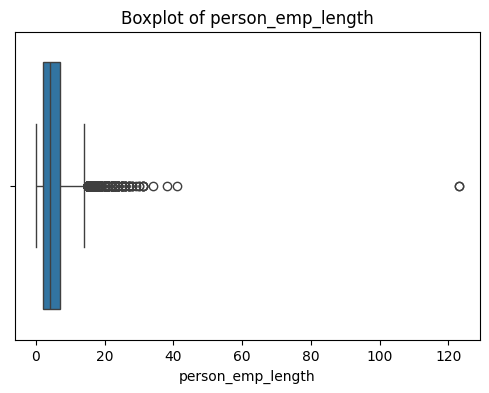

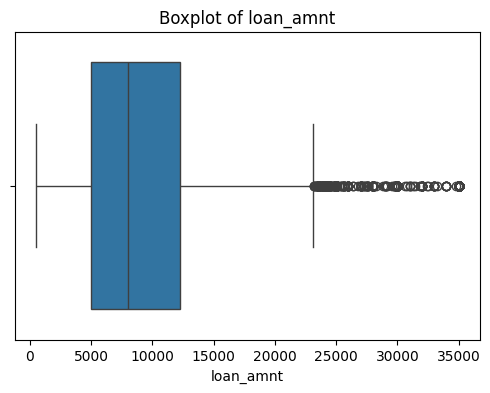

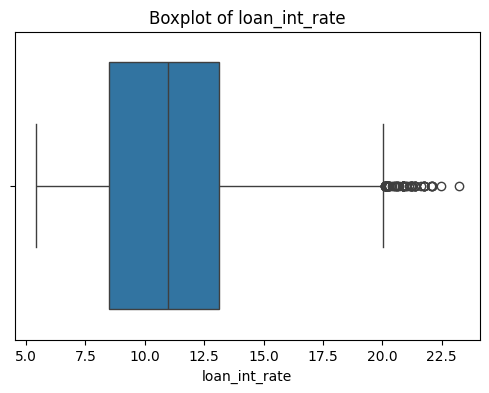

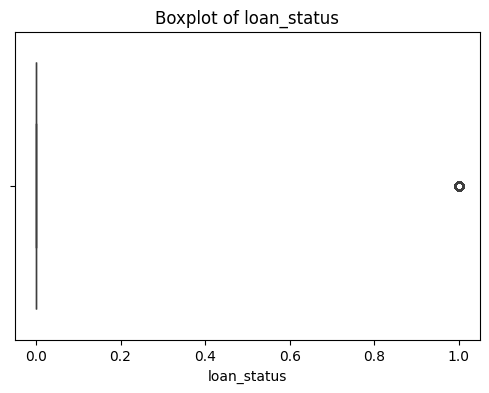

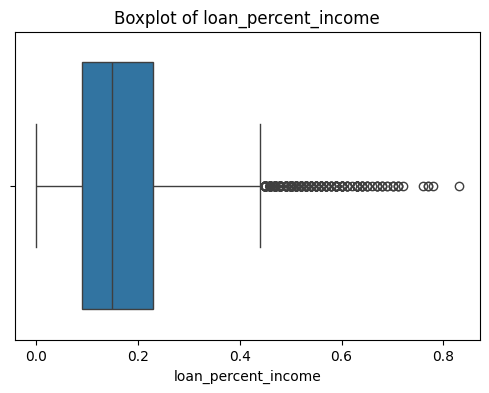

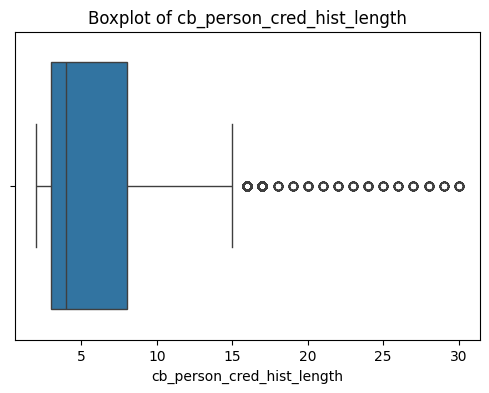


Categorical Columns:
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

Value Counts for person_home_ownership:
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

Value Counts for loan_intent:
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

Value Counts for loan_grade:
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

Value Counts for cb_person_default_on_file:
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


In [3]:
# ==============================
# MEMBER 3
# EDA + Outlier Detection
# ==============================

# Target variable distribution
print("Loan Status Distribution:")
print(df["loan_status"].value_counts())

print("\nLoan Status Percentage:")
print(df["loan_status"].value_counts(normalize=True) * 100)

# Target distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


# Histograms for numerical columns
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


# Boxplots for numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("\nCategorical Columns:")
print(categorical_columns)

# Display value counts
for column in categorical_columns:
    print(f"\nValue Counts for {column}:")
    print(df[column].value_counts())